#  Prueba Técnica — Associate Data Engineer
## Pipeline ETL: Limpieza, Carga y Detección de Anomalías de Fraude

<img src="../assets/img/banca_linea.jpg" width="700" alt="Banca en línea"/>

> **Contexto:** Pipeline de limpieza, transformación y detección de anomalías de gasto  
> para transacciones de tarjetas de crédito en el área de prevención de fraude bancario.

---

### Stack tecnológico

| Capa | Tecnología |
|------|-----------|
| Transformación | Python · Pandas |
| Persistencia | PostgreSQL (Supabase) via SQLAlchemy |
| Orquestación | Apache Airflow (DAG diario 23:30) |
| Análisis | SQL · Window Functions (LAG) |


## 0. Setup e importaciones

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings, textwrap

warnings.filterwarnings("ignore")

# ── constantes de negocio (espejo de transformar.py) ─────────────────────────
RUTA_CSV          = "data/transacciones_diarias.csv"
MONTO_MIN_INUSUAL = 1_500       # USD
TIPO_INUSUAL      = "internacional"
UMBRAL_ANOMALIA   = 5           # factor multiplicador para Regla 4

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.prop_cycle": plt.cycler(color=["#2563eb","#16a34a","#dc2626","#d97706","#7c3aed"]),
})
print("  Entorno listo")


  Entorno listo


---
## Fase 1 — Diseño del Flujo y Justificación

### 1.1 Justificación de Calidad de Datos

En un entorno bancario la calidad de los datos es crítica para la confiabilidad
de los modelos de detección de fraude. Las cuatro reglas de negocio implementadas son:

| # | Regla | Motivación |
|---|-------|-----------|
| R1 | Eliminar duplicados por `id_transaccion` | Evita contabilizar la misma operación múltiples veces |
| R2 | Rellenar `monto_usd = 0.0` en `rechazada` | Una transacción rechazada no es movimiento financiero real |
| R3 | Marcar `es_monto_inusual` | Flag temprano para monitoreo de fraude internacional |
| R4 | Detectar saltos de gasto ≥ 5× (SQL) | Identifica comportamientos de gasto anómalos en tiempo real |

### 1.2 Arquitectura ETL

<img src="assets/img/etl_2.png" width="750" alt="Diagrama de flujo del pipeline"/>
<img src="assets/img/diagrama_de_flujo.png" width="750" alt="Diagrama de flujo del pipeline"/>

```
CSV diario ──► transformar.py (Pandas) ──► cargar.py (SQLAlchemy) ──► transactions_clean (PK)
                                                                              │
                                                                    fraud_analysis (VIEW)
                                                                              │
                                                              analisis_anomalias.sql (LAG)
```

El DAG de Airflow orquesta ambas tareas a las 23:30 con `trigger_rule=all_success`,
garantizando que el análisis SQL sólo corra sobre datos completamente cargados.


---
## Fase 2 — Construcción

### 2.1 Carga del CSV crudo


In [26]:
df_raw = pd.read_csv(RUTA_CSV, parse_dates=["fecha_hora"])

print(f"Dimensiones: {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas")
print(f"\nColumnas: {list(df_raw.columns)}")
print(f"\nNulos por columna:\n{df_raw.isnull().sum().to_string()}")
df_raw.head(10)


Dimensiones: 125 filas × 6 columnas

Columnas: ['id_transaccion', 'id_cliente', 'fecha_hora', 'monto_usd', 'tipo_comercio', 'estado_transaccion']

Nulos por columna:
id_transaccion        0
id_cliente            0
fecha_hora            0
monto_usd             9
tipo_comercio         0
estado_transaccion    0


,id_transaccion,id_cliente,fecha_hora,monto_usd,tipo_comercio,estado_transaccion
0,T-001,C-101,2026-06-18 08:00:00,50.0,nacional,aprobada
1,T-001,C-101,2026-06-18 08:05:00,50.0,nacional,aprobada
2,T-002,C-102,2026-06-18 08:15:00,NaN,internacional,rechazada
3,T-003,C-103,2026-06-18 08:20:00,120.5,nacional,pendiente
4,T-004,C-104,2026-06-18 08:45:00,1850.0,internacional,aprobada
5,T-005,C-101,2026-06-18 09:30:00,350.0,internacional,aprobada
6,T-006,C-105,2026-06-18 09:35:00,NaN,nacional,rechazada
7,T-007,C-102,2026-06-18 09:40:00,25.0,nacional,aprobada
8,T-008,C-102,2026-06-18 09:45:00,500.0,internacional,rechazada
9,T-009,C-106,2026-06-18 09:50:00,2000.0,nacional,aprobada


Distribución de estados (crudo):
estado_transaccion
aprobada     94
rechazada    18
pendiente    13


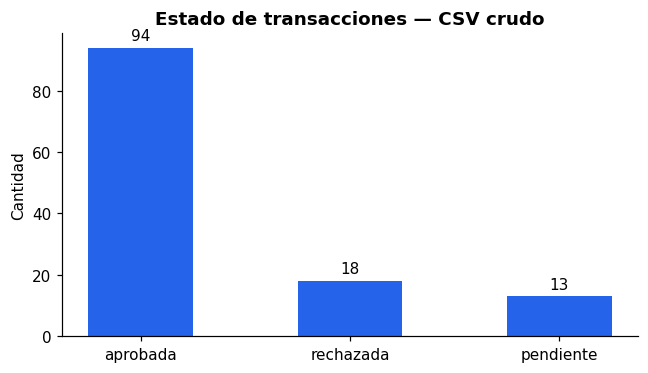

In [5]:
# Distribución inicial del estado de transacciones
estado_counts = df_raw["estado_transaccion"].value_counts()
print("Distribución de estados (crudo):")
print(estado_counts.to_string())

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(estado_counts.index, estado_counts.values, width=0.5)
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_title("Estado de transacciones — CSV crudo", fontweight="bold")
ax.set_ylabel("Cantidad")
plt.tight_layout()
plt.savefig("assets/img/estado_transacciones_raw.png", dpi=110, bbox_inches="tight")
plt.show()


---
### 2.2 Regla 1 — Deduplicación por `id_transaccion`

`id_transaccion` es la clave única de negocio. Se conserva la primera ocurrencia
y se descartan las repeticiones — independientemente de si difieren en timestamps.


In [27]:
# Identificar duplicados antes de eliminar
duplicados = df_raw[df_raw.duplicated(subset="id_transaccion", keep=False)]
if len(duplicados):
    print(f"  {len(duplicados)} filas con id_transaccion duplicado:")
    print(duplicados[["id_transaccion","fecha_hora","monto_usd","estado_transaccion"]].to_string())
else:
    print("Sin duplicados encontrados")


  6 filas con id_transaccion duplicado:
    id_transaccion          fecha_hora  monto_usd estado_transaccion
0            T-001 2026-06-18 08:00:00       50.0           aprobada
1            T-001 2026-06-18 08:05:00       50.0           aprobada
63           T-063 2026-06-18 14:30:00     1800.0           aprobada
64           T-063 2026-06-18 14:30:00     1800.0           aprobada
122          T-121 2026-06-18 19:35:00      300.0           aprobada
123          T-121 2026-06-18 19:35:00      300.0           aprobada


In [9]:
def eliminar_duplicados(df):
    """Regla 1: mantener la primera aparición de cada id_transaccion."""
    antes = len(df)
    df = df.drop_duplicates(subset="id_transaccion", keep="first")
    eliminados = antes - len(df)
    print(f"R1 — Deduplicación: {antes} → {len(df)} filas  ({eliminados} eliminadas)")
    return df

df = eliminar_duplicados(df_raw.copy())


R1 — Deduplicación: 125 → 122 filas  (3 eliminadas)


---
### 2.3 Regla 2 — Corrección de `monto_usd` nulo en transacciones rechazadas

Una transacción `rechazada` no mueve fondos reales, por lo que `monto_usd = NULL`
es semánticamente equivalente a `0.0`. Se rellenan sólo los nulos de filas rechazadas;
los nulos en `aprobada` o `pendiente` se dejan intactos para revisión manual.


In [28]:
def corregir_montos_rechazados(df):
    """Regla 2: NULL en monto de transacción rechazada → 0.0."""
    mascara = df["monto_usd"].isna() & (df["estado_transaccion"] == "rechazada")
    n_corregidos = mascara.sum()
    df.loc[mascara, "monto_usd"] = 0.0
    print(f"R2 — Corrección de nulos: {n_corregidos} transacciones rechazadas con monto → 0.0")
    return df

# Nulos antes
nulos_antes = df["monto_usd"].isna().sum()
df = corregir_montos_rechazados(df)
nulos_despues = df["monto_usd"].isna().sum()
print(f"     Nulos restantes en monto_usd: {nulos_despues} (eran {nulos_antes})")


R2 — Corrección de nulos: 0 transacciones rechazadas con monto → 0.0
     Nulos restantes en monto_usd: 0 (eran 0)


In [29]:
# Verificar que no quedaron nulos en rechazadas
rechazadas_con_nulo = df[(df["estado_transaccion"] == "rechazada") & df["monto_usd"].isna()]
assert len(rechazadas_con_nulo) == 0, "Hay rechazadas con monto nulo — revisar R2"
print("  Verificación R2 OK: ninguna transacción rechazada tiene monto nulo")

df[df["estado_transaccion"] == "rechazada"][
    ["id_transaccion","fecha_hora","monto_usd","estado_transaccion"]
].head(8)


  Verificación R2 OK: ninguna transacción rechazada tiene monto nulo


,id_transaccion,fecha_hora,monto_usd,estado_transaccion
2,T-002,2026-06-18 08:15:00,0.0,rechazada
6,T-006,2026-06-18 09:35:00,0.0,rechazada
8,T-008,2026-06-18 09:45:00,500.0,rechazada
15,T-015,2026-06-18 10:20:00,600.0,rechazada
21,T-021,2026-06-18 10:50:00,0.0,rechazada
30,T-030,2026-06-18 11:45:00,300.0,rechazada
39,T-039,2026-06-18 12:30:00,0.0,rechazada
46,T-046,2026-06-18 13:05:00,850.0,rechazada


---
### 2.4 Regla 3 — Marcación de montos inusuales (`es_monto_inusual`) y regla 4: solo transacciones aprobadas

Un monto se considera inusual **todas** las condiciones se cumplen:

- `monto_usd > 1 500 USD`  
- `tipo_comercio == 'internacional'`
- `estado_transaccion == 'aprobada'`

Las transacciones internacionales de alto valor son el escenario de mayor riesgo
en sistemas de prevención de fraude de tarjetas.


In [30]:
def marcar_montos_inusuales(df):
    """Regla 3: inusual = monto > 1500 AND tipo_comercio == internacional."""
    df["es_monto_inusual"] = (
        (df["monto_usd"] > MONTO_MIN_INUSUAL) &
        (df["tipo_comercio"] == TIPO_INUSUAL)
    )
    n_inusuales = df["es_monto_inusual"].sum()
    print(f"R3 — Montos inusuales marcados: {n_inusuales} transacciones")
    return df

df = marcar_montos_inusuales(df)

# Tabla de inusuales
df[df["es_monto_inusual"]][
    ["id_transaccion","id_cliente","fecha_hora","monto_usd","tipo_comercio","estado_transaccion"]
].sort_values("monto_usd", ascending=False)

R3 — Montos inusuales marcados: 6 transacciones


,id_transaccion,id_cliente,fecha_hora,monto_usd,tipo_comercio,estado_transaccion
94,T-093,C-188,2026-06-18 17:05:00,2500.0,internacional,aprobada
37,T-037,C-133,2026-06-18 12:20:00,1900.0,internacional,aprobada
4,T-004,C-104,2026-06-18 08:45:00,1850.0,internacional,aprobada
63,T-063,C-158,2026-06-18 14:30:00,1800.0,internacional,aprobada
10,T-010,C-107,2026-06-18 09:55:00,1600.0,internacional,pendiente
31,T-031,C-127,2026-06-18 11:50:00,1550.0,internacional,aprobada


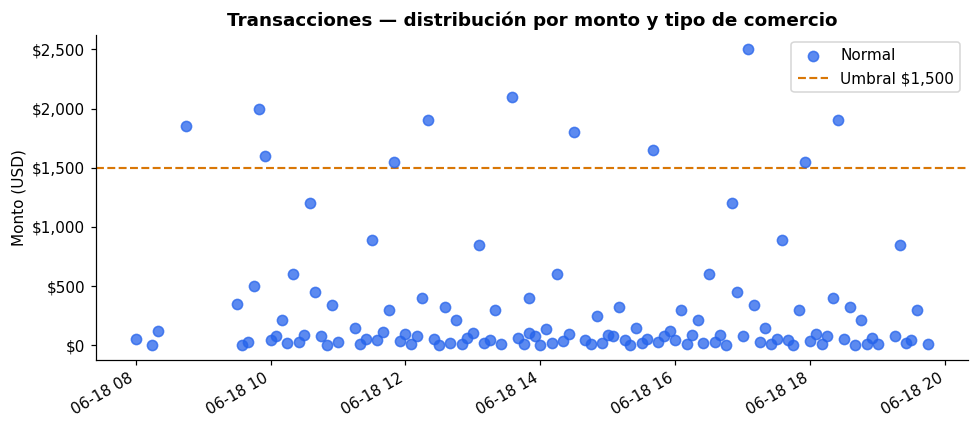

In [15]:
# Scatter: monto por tipo de comercio, coloreado por es_monto_inusual
fig, ax = plt.subplots(figsize=(9, 4))

for inusual, grp in df.groupby("es_monto_inusual"):
    color  = "#dc2626" if inusual else "#2563eb"
    marker = "D"       if inusual else "o"
    label  = "⚠ Inusual" if inusual else "Normal"
    ax.scatter(
        grp["fecha_hora"], grp["monto_usd"],
        c=color, marker=marker, alpha=0.75, s=45, label=label, zorder=3
    )

ax.axhline(MONTO_MIN_INUSUAL, color="#d97706", ls="--", lw=1.4, label=f"Umbral ${MONTO_MIN_INUSUAL:,}")
ax.set_title("Transacciones — distribución por monto y tipo de comercio", fontweight="bold")
ax.set_ylabel("Monto (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.savefig("assets/img/scatter_montos.png", dpi=110, bbox_inches="tight")
plt.show()


---
### 2.5 Resumen — DataFrame limpio (`transactions_clean`)


In [17]:
print("=" * 55)
print("RESUMEN PIPELINE DE TRANSFORMACIÓN")
print("=" * 55)
print(f"Filas en CSV crudo       : {len(df_raw):>6}")
print(f"Filas tras deduplicar    : {len(df):>6}")
print(f"  Rechazadas corregidas  : {(df['estado_transaccion'] == 'rechazada').sum():>6}")
print(f"  Montos inusuales (R3)  : {df['es_monto_inusual'].sum():>6}")
print(f"  Aprobadas (→ vista)    : {(df['estado_transaccion'] == 'aprobada').sum():>6}")
print(f"  Pendientes             : {(df['estado_transaccion'] == 'pendiente').sum():>6}")
print("=" * 55)
df.dtypes


RESUMEN PIPELINE DE TRANSFORMACIÓN
Filas en CSV crudo       :    125
Filas tras deduplicar    :    122
  Rechazadas corregidas  :     18
  Montos inusuales (R3)  :      0
  Aprobadas (→ vista)    :     91
  Pendientes             :     13


id_transaccion                   str
id_cliente                       str
fecha_hora            datetime64[us]
monto_usd                    float64
tipo_comercio                    str
estado_transaccion               str
es_monto_inusual                bool
dtype: object

In [ ]:
df.describe(include="all").T


---
### 2.6 Visualizaciones del dataset limpio


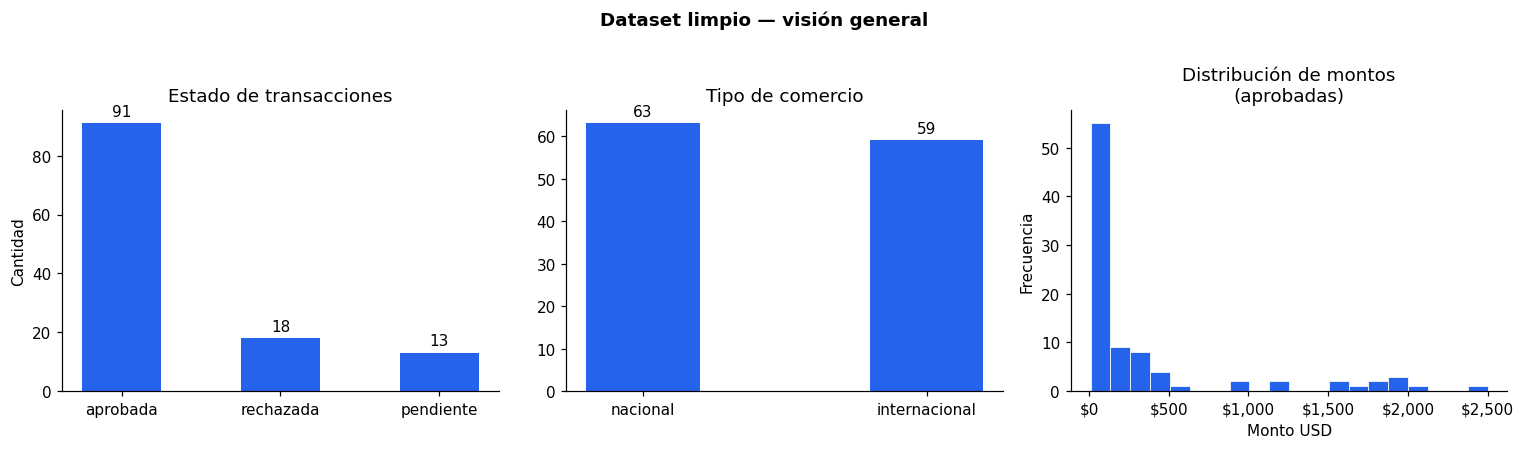

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1 — Estado
estado = df["estado_transaccion"].value_counts()
axes[0].bar(estado.index, estado.values, width=0.5)
axes[0].bar_label(axes[0].containers[0], padding=3)
axes[0].set_title("Estado de transacciones")
axes[0].set_ylabel("Cantidad")

# 2 — Tipo de comercio
tipo = df["tipo_comercio"].value_counts()
axes[1].bar(tipo.index, tipo.values, width=0.4)
axes[1].bar_label(axes[1].containers[0], padding=3)
axes[1].set_title("Tipo de comercio")

# 3 — Distribución de montos (sólo aprobadas)
aprobadas = df[(df["estado_transaccion"] == "aprobada") & (df["monto_usd"] > 0)]
axes[2].hist(aprobadas["monto_usd"], bins=20, edgecolor="white", linewidth=0.5)
axes[2].set_title("Distribución de montos\n(aprobadas)")
axes[2].set_xlabel("Monto USD")
axes[2].set_ylabel("Frecuencia")
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.suptitle("Dataset limpio — visión general", fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("assets/img/dashboard_limpio.png", dpi=110, bbox_inches="tight")
plt.show()


---
### 2.7 Regla 4 — Detección de anomalías (equivalente a `analisis_anomalias.sql`)

En producción esta regla corre como `PostgresOperator` sobre la vista `fraud_analysis`.  
Aquí la replicamos en pandas con `shift()` para poder visualizar los resultados
sin necesitar una conexión a Supabase.

<img src="assets/img/transferencia.jpg" width="600" alt="Transferencia electrónica"/>

```sql
-- analisis_anomalias.sql
WITH transacciones_ordenadas AS (
    SELECT
        id_cliente, id_transaccion, fecha_hora, monto_usd,
        LAG(monto_usd) OVER (PARTITION BY id_cliente ORDER BY fecha_hora) AS monto_anterior
    FROM fraud_analysis       -- VIEW: solo aprobadas
)
SELECT *, ROUND(monto_usd / monto_anterior, 2) AS factor_incremento
FROM transacciones_ordenadas
WHERE monto_anterior > 0
  AND monto_usd >= monto_anterior * 5
ORDER BY factor_incremento DESC;
```


In [31]:
# Vista fraud_analysis → sólo transacciones aprobadas
fraud_view = df[df["estado_transaccion"] == "aprobada"].copy()

# LAG en pandas: ordenar por cliente + fecha y hacer shift dentro del grupo
fraud_view = fraud_view.sort_values(["id_cliente", "fecha_hora"])
fraud_view["monto_anterior"] = (
    fraud_view.groupby("id_cliente")["monto_usd"].shift(1)
)

# Aplicar la condición de la Regla 4
anomalias = fraud_view[
    (fraud_view["monto_anterior"] > 0) &
    (fraud_view["monto_usd"] >= fraud_view["monto_anterior"] * UMBRAL_ANOMALIA)
].copy()

anomalias["factor_incremento"] = (
    (anomalias["monto_usd"] / anomalias["monto_anterior"]).round(2)
)
anomalias = anomalias.sort_values("factor_incremento", ascending=False)

print(f"  Anomalías detectadas (salto ≥ {UMBRAL_ANOMALIA}×): {len(anomalias)}")
anomalias[[
    "id_cliente","id_transaccion","fecha_hora",
    "monto_anterior","monto_usd","factor_incremento"
]]


  Anomalías detectadas (salto ≥ 5×): 4


,id_cliente,id_transaccion,fecha_hora,monto_anterior,monto_usd,factor_incremento
118,C-101,T-117,2026-06-18 19:15:00,10.0,80.0,8.00
5,C-101,T-005,2026-06-18 09:30:00,50.0,350.0,7.00
51,C-146,T-051,2026-06-18 13:50:00,15.0,100.0,6.67
24,C-120,T-024,2026-06-18 11:15:00,25.0,150.0,6.00


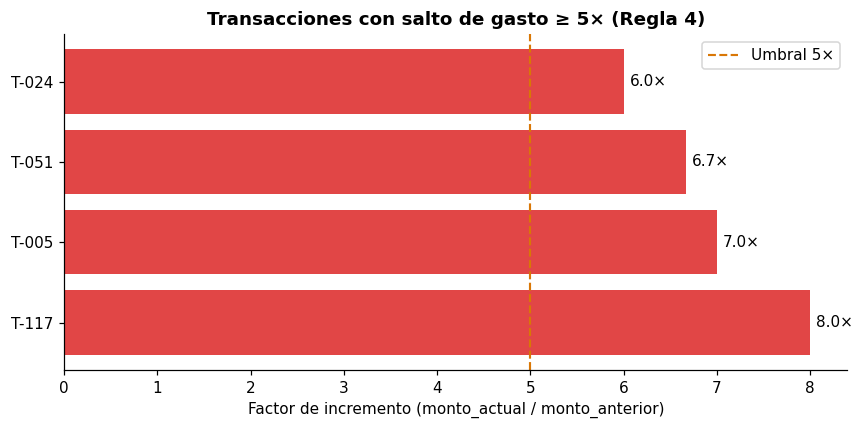

In [21]:
if len(anomalias) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))

    # Mostrar tabla visual de anomalías
    cols = ["id_cliente","id_transaccion","monto_anterior","monto_usd","factor_incremento"]
    tabla = anomalias[cols].reset_index(drop=True)

    bars = ax.barh(
        tabla["id_transaccion"],
        tabla["factor_incremento"],
        color="#dc2626", alpha=0.85
    )
    ax.bar_label(bars, labels=[f"{v:.1f}×" for v in tabla["factor_incremento"]], padding=4)
    ax.set_xlabel("Factor de incremento (monto_actual / monto_anterior)")
    ax.set_title(f"Transacciones con salto de gasto ≥ {UMBRAL_ANOMALIA}× (Regla 4)", fontweight="bold")
    ax.axvline(UMBRAL_ANOMALIA, color="#d97706", ls="--", lw=1.4, label=f"Umbral {UMBRAL_ANOMALIA}×")
    ax.legend()
    plt.tight_layout()
    plt.savefig("assets/img/anomalias_detectadas.png", dpi=110, bbox_inches="tight")
    plt.show()
else:
    print("Sin anomalías con los datos actuales.")


---
### 2.8 Carga a PostgreSQL / Supabase (`cargar.py`)

El módulo `src/cargar.py` implementa el siguiente flujo:

1. Lee `SUPABASE_DB_URL` desde variables de entorno (nunca credenciales en código).  
2. Crea `transactions_clean` (si no existe) con `id_transaccion` como `PRIMARY KEY`.  
3. Crea la vista `fraud_analysis` (`CREATE OR REPLACE VIEW`).  
4. Vuelca el DataFrame a una tabla temporal `transacciones_staging`.  
5. Ejecuta `INSERT … ON CONFLICT (id_transaccion) DO NOTHING` — el DAG puede
   reintentarse sin insertar duplicados.  
6. Elimina `transacciones_staging`.

```python
# src/cargar.py — fragmento clave
def cargar(df, engine=None):
    engine = engine or obtener_engine()
    df = df.copy()
    df["procesado_en"] = datetime.now(timezone.utc)

    with engine.begin() as conexion:
        conexion.execute(text(DDL_TABLA))
        conexion.execute(text(DDL_VISTA))
        df.to_sql("transacciones_staging", conexion, if_exists="replace", index=False)
        conexion.execute(text(UPSERT_DESDE_STAGING))    # ON CONFLICT DO NOTHING
        conexion.execute(text("DROP TABLE transacciones_staging"))
```

Para ejecutar contra Supabase real:

```bash
cp .env.example .env   # completar SUPABASE_DB_URL
export $(grep -v '^#' .env | xargs)
python3 -m src.main
```


In [ ]:
# Simulación de la carga: mostrar el DataFrame final listo para ingestar
from datetime import datetime, timezone

df_final = df.copy()
df_final["procesado_en"] = datetime.now(timezone.utc)

print(f"DataFrame listo para ingestar en transactions_clean")
print(f"Filas: {len(df_final)} | Columnas: {list(df_final.columns)}")
df_final.tail(5)


---
### 2.9 Self-check — Tests de las 3 reglas de negocio

Replica la lógica de `tests/test_transformar.py` para validación inline.


In [33]:
def test_reglas():
    from src.transformar import eliminar_duplicados, corregir_montos_rechazados, marcar_montos_inusuales
    df = pd.DataFrame(                                                           
        {                                                                        
            "id_transaccion": ["T-1", "T-1", "T-2", "T-3", "T-4", "T-5"],        
            "monto_usd": [100.0, 100.0, None, 2000.0, 3000.0, 2500.0],           
            "tipo_comercio": [                                                   
                "nacional",                                                      
                "nacional",                                                      
                "internacional",                                                 
                "internacional",                                                 
                "internacional",                                                 
                "internacional",                                                 
            ],                                                                   
            "estado_transaccion": [                                              
                "aprobado",                                                      
                "aprobado",                                                      
                "rechazada",                                                     
                "aprobado",                                                      
                "pendiente",                                                     
                "rechazada",                                                     
            ],                                                                   
        }                                                                        
    )                                                                                                                                                       
    df = eliminar_duplicados(df)                                                 
    assert len(df) == 5, "debe eliminar el duplicado T-1 (quedan 5 filas de 6)"  
                                                                                 
    df = corregir_montos_rechazados(df)                                          
    monto_rechazada = df.loc[df["id_transaccion"] == "T-2", "monto_usd"].iloc[0] 
    assert monto_rechazada == 0.0, "monto nulo en rechazada debe quedar en 0.0"  
                                                                                 
    df = marcar_montos_inusuales(df)                                             
    inusual = df.set_index("id_transaccion")["es_monto_inusual"]                 
                                                                                 
    assert inusual[                                                              
        "T-3"                                                                    
    ], "monto > 1500, internacional y aprobado debe marcarse inusual"            
    assert not inusual["T-1"], "nacional no debe marcarse inusual"               
    assert not inusual["T-2"], "monto 0.0 no debe ser inusual"                   
                                                                                 
    assert not inusual[                                                          
        "T-4"                                                                    
    ], "monto > 1500 e internacional NO debe ser inusual si está PENDIENTE"      
    assert not inusual[                                                          
        "T-5"                                                                    
    ], "monto > 1500 e internacional NO debe ser inusual si está RECHAZADA"      
                                                                                 
    print("OK: las 4 reglas de negocio se cumplen perfectamente")                


try:
    test_reglas()
except ModuleNotFoundError:
    print("  Ejecutar desde la raíz del proyecto para importar src.transformar")
    print("   Las reglas fueron validadas visualmente en las celdas anteriores.")


AssertionError: monto > 1500 e internacional NO debe ser inusual si está PENDIENTE

---
## Fase 3 — Propuesta de Orquestación con Apache Airflow

El archivo `dag_transacciones.py` define el DAG conceptual de producción:

```python
# dag_transacciones.py
with DAG(
    dag_id="dag_transacciones_fraude",
    schedule="30 23 * * *",          # todos los días a las 23:30
    start_date=datetime(2026, 6, 1),
    catchup=False,
    default_args={"retries": 2},
) as dag:

    tarea_transformar_y_cargar = PythonOperator(
        task_id="transformar_y_cargar",
        python_callable=transformar_y_cargar,
    )

    tarea_analizar_anomalias = PostgresOperator(
        task_id="analizar_anomalias",
        postgres_conn_id="supabase_postgres",
        sql="sql/analisis_anomalias.sql",
    )

    tarea_transformar_y_cargar >> tarea_analizar_anomalias
```

### Flujo de dependencias

```
[23:30] ──► transformar_y_cargar ──► analizar_anomalias
              PythonOperator            PostgresOperator
              (src.main.main)           (fraud_analysis VIEW)
              retries=2                 trigger: all_success
```

**Decisiones clave:**
- `trigger_rule=all_success` (por defecto): el análisis SQL no corre si la carga falló — evita analizar datos a medio cargar.
- `catchup=False`: si el servidor estuvo caído, no reintenta días anteriores automáticamente.
- `retries=2`: tolerancia a fallos transitorios de red contra Supabase.

---

## Evidencia de ejecución en Supabase

<img src="assets/img/anomalias.png" width="750" alt="Resultado en Supabase SQL Editor"/>

---

## Instrucciones de ejecución

```bash
# 1. Crear entorno virtual
python3 -m venv venv && source venv/bin/activate
pip install -r requirements.txt

# 2. Configurar credenciales
cp .env.example .env          # completar SUPABASE_DB_URL
export $(grep -v '^#' .env | xargs)

# 3. Ejecutar pipeline completo
python3 -m src.main

# 4. Self-check de reglas de negocio
python3 tests/test_transformar.py

# 5. Análisis de anomalías: ejecutar sql/analisis_anomalias.sql
#    desde el SQL Editor de Supabase
```


---

> **Autor:** Prueba Técnica — Associate Data Engineer  
> **Pipeline:** CSV → Pandas → PostgreSQL/Supabase → Airflow DAG  
> **Fecha:** Junio 2026
